# Tugas 3 — Klasifikasi Gambar dengan CNN
**Dataset:** Intel Image Classification (3 kelas: buildings, forest, mountain) <br>
**Metode:** Convolutional Neural Network (CNN) <br><br>

**Kelompok:** Kelompok 1 : 
- Affan Suhendar
- Amirul Mirdas

## 1. Import Library

In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 2. Subsample Dataset

Subsample dilakukan untuk menyesuaikan kapasitas komputasi lokal sekaligus memenuhi ketentuan tugas. Dataset asli memiliki **6 kelas** dengan masing-masing sekitar **2.000 gambar** pada data train dan **400 gambar** pada data test, jumlah yang cukup besar untuk dijalankan secara lokal.

Oleh karena itu, dilakukan dua penyesuaian berikut:

- **Jumlah kelas** dikurangi menjadi **3 kelas** (`buildings`, `forest`, `mountain`), sesuai batas maksimal yang disyaratkan tugas.
- **Jumlah gambar** dikurangi menjadi **400 gambar/kelas** untuk train dan **100 gambar/kelas** untuk test, jauh di atas batas minimum 100 gambar yang disyaratkan.

Proses subsample dilakukan secara acak (*random sampling*) menggunakan modul `random` dan `shutil` bawaan Python, dan hasilnya disimpan ke direktori `data_small/` agar tidak mengubah dataset asli.

In [ ]:
# subsampling gambar

CLASSES    = ['buildings', 'forest', 'mountain']
N_TRAIN    = 400   # gambar per kelas untuk train
N_TEST     = 100   # gambar per kelas untuk test

def subsample(src, dst, n):
    os.makedirs(dst, exist_ok=True)
    files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    chosen = random.sample(files, min(n, len(files)))
    for f in chosen:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    print(f'  {dst}: {len(chosen)} gambar')

for cls in CLASSES:
    subsample(f'seg_train/seg_train/{cls}', f'data_small/train/{cls}', N_TRAIN)
    subsample(f'seg_test/seg_test/{cls}',  f'data_small/test/{cls}',  N_TEST)

print('\nSubsample berhasil')

  data_small/train/buildings: 400 gambar
  data_small/test/buildings: 100 gambar
  data_small/train/forest: 400 gambar
  data_small/test/forest: 100 gambar
  data_small/train/mountain: 400 gambar
  data_small/test/mountain: 100 gambar

Subsample selesai!


## 3. Load & Preprocessing Dataset

In [3]:
IMG_SIZE   = 64          # resize ke 64x64
CLASSES    = ['buildings', 'forest', 'mountain']
TRAIN_DIR  = 'data_small/train'
TEST_DIR   = 'data_small/test'

def load_images(base_dir, classes, img_size):
    X, y = [], []
    for label, cls in enumerate(classes):
        folder = os.path.join(base_dir, cls)
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            try:
                img = Image.open(fpath).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img))
                y.append(label)
            except:
                pass
    return np.array(X, dtype='float32'), np.array(y)

X_train_full, y_train_full = load_images(TRAIN_DIR, CLASSES, IMG_SIZE)
X_test,       y_test       = load_images(TEST_DIR,  CLASSES, IMG_SIZE)

print('Shape X_train_full :', X_train_full.shape)
print('Shape X_test       :', X_test.shape)

Shape X_train_full : (1200, 64, 64, 3)
Shape X_test       : (300, 64, 64, 3)


In [4]:
# Normalisasi pixel 0-255 → 0-1
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

# Split train → train + validation (80:20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("         PEMBAGIAN DATASET (80:20)")

print(f"\n{'TRAIN (80%)':-^45}")
print(f"  Total        : {X_train.shape[0]} gambar")
for i, cls in enumerate(CLASSES):
    jumlah = np.sum(y_train == i)
    print(f"  {cls:<12} : {jumlah} gambar")

print(f"\n{'VALIDATION (20%)':-^45}")
print(f"  Total        : {X_val.shape[0]} gambar")
for i, cls in enumerate(CLASSES):
    jumlah = np.sum(y_val == i)
    print(f"  {cls:<12} : {jumlah} gambar")

print(f"\n{'TEST (data terpisah)':-^45}")
print(f"  Total        : {X_test.shape[0]} gambar")
for i, cls in enumerate(CLASSES):
    jumlah = np.sum(y_test == i)
    print(f"  {cls:<12} : {jumlah} gambar")


print(f" \n \nTotal : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} gambar")


         PEMBAGIAN DATASET (80:20)

-----------------TRAIN (80%)-----------------
  Total        : 960 gambar
  buildings    : 320 gambar
  forest       : 320 gambar
  mountain     : 320 gambar

--------------VALIDATION (20%)---------------
  Total        : 240 gambar
  buildings    : 80 gambar
  forest       : 80 gambar
  mountain     : 80 gambar

------------TEST (data terpisah)-------------
  Total        : 300 gambar
  buildings    : 100 gambar
  forest       : 100 gambar
  mountain     : 100 gambar
 
 
Total : 1500 gambar


## 4. Visualisasi Sampel Data

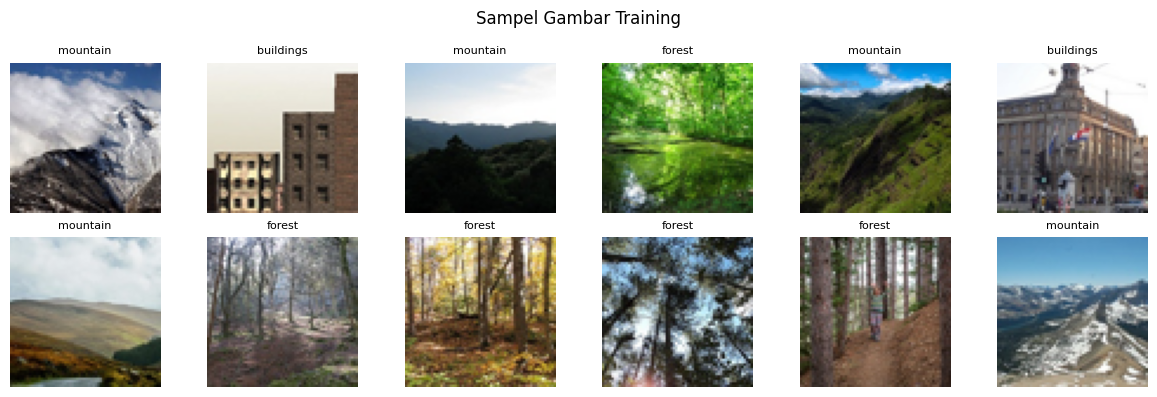

In [5]:
plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(2, 6, i+1)
    idx = random.randint(0, len(X_train)-1)
    plt.imshow(X_train[idx])
    plt.title(CLASSES[y_train[idx]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sampel Gambar Training', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Membangun Model CNN
Kami akan membangun **2 konfigurasi model** untuk dibandingkan:
- **Model 1:** CNN sederhana (2 Conv layer)
- **Model 2:** CNN lebih dalam (3 Conv layer + BatchNormalization)

### Model 1 CNN Sederhana

In [6]:
IMG_SHAPE  = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = len(CLASSES)

model1 = Sequential([
    # Block 1
    Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=IMG_SHAPE),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(pool_size=2),
    Dropout(0.25),

    # Fully Connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='Model_1_Sederhana')

model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
model1.summary()

Model: "Model_1_Sederhana"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,059 (8.08 MB)

 Trainable params: 2,117,059 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history1 = model1.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    verbose=1,
    validation_data=(X_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4771 - loss: 1.1693 - val_accuracy: 0.7250 - val_loss: 0.7834
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6771 - loss: 0.7224 - val_accuracy: 0.5833 - val_loss: 0.7369
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7052 - loss: 0.6547 - val_accuracy: 0.6875 - val_loss: 0.6524
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7344 - loss: 0.5753 - val_accuracy: 0.6917 - val_loss: 0.6197
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7875 - loss: 0.4824 - val_accuracy: 0.7542 - val_loss: 0.5205
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8323 - loss: 0.4103 - val_accuracy: 0.7583 - val_loss: 0.4974
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8406 - loss: 0.4098 - val_accuracy: 0.8292 - val_loss: 0.4364
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8625 - loss: 0.3519 - val_accuracy: 0.8542 - v

### Model 2  CNN Lebih Dalam + BatchNormalization

In [8]:
model2 = Sequential([
    # Block 1
    Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=IMG_SHAPE),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),
    Dropout(0.2),

    # Block 2
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),
    Dropout(0.2),

    # Block 3
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),
    Dropout(0.2),

    # Fully Connected
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name='Model_2_Dalam_BatchNorm')

model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
model2.summary()

Model: "Model_2_Dalam_BatchNorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,323 (8.36 MB)

 Trainable params: 2,191,875 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
history2 = model2.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    verbose=1,
    validation_data=(X_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6771 - loss: 1.6296 - val_accuracy: 0.4000 - val_loss: 1.4069
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8167 - loss: 0.5976 - val_accuracy: 0.5833 - val_loss: 1.3596
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8510 - loss: 0.4215 - val_accuracy: 0.4750 - val_loss: 3.1055
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8677 - loss: 0.3590 - val_accuracy: 0.4583 - val_loss: 4.7107
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8865 - loss: 0.3072 - val_accuracy: 0.4542 - val_loss: 5.3970
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9021 - loss: 0.2510 - val_accuracy: 0.3958 - val_loss: 6.7883
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9219 - loss: 0.2271 - val_accuracy: 0.3625 - val_loss: 8.4587
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9333 - loss: 0.1850 - val_accuracy: 0.3875 - v

## 6. Visualisasi Training — Loss & Accuracy

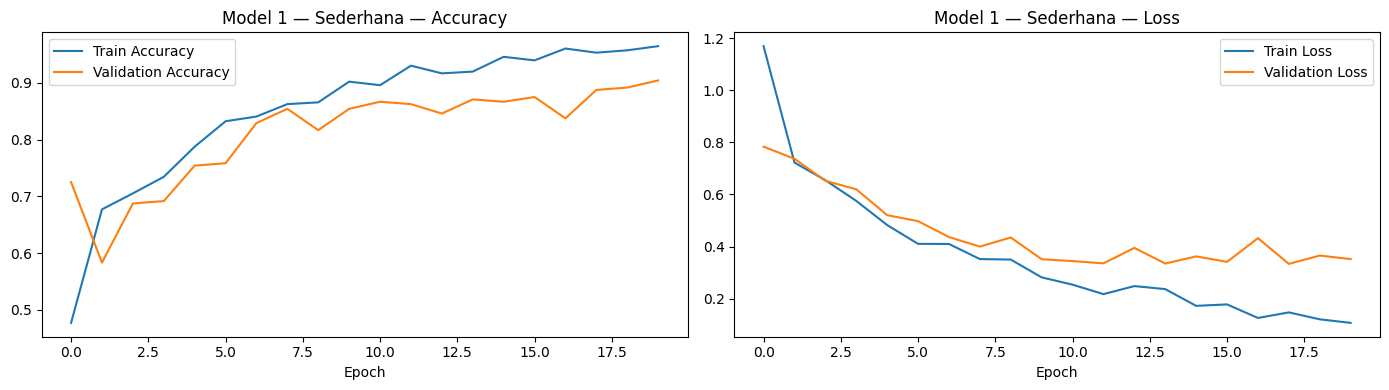

In [10]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, 'Model 1 — Sederhana')

### Interpretasi Grafik Training  Model 1 (Sederhana)

Berdasarkan grafik training Model 1:
- **Accuracy**: Akurasi train dan validasi meningkat secara konsisten seiring bertambahnya epoch, 
  menunjukkan bahwa model berhasil belajar dari data training.
- **Loss**: Nilai loss pada train dan validasi menurun secara stabil, mengindikasikan proses 
  training berjalan dengan baik tanpa gejala overfitting yang signifikan.
- Kedua kurva (train dan validasi) terlihat berdekatan, artinya model memiliki kemampuan 
  generalisasi yang cukup baik terhadap data yang belum pernah dilihat.

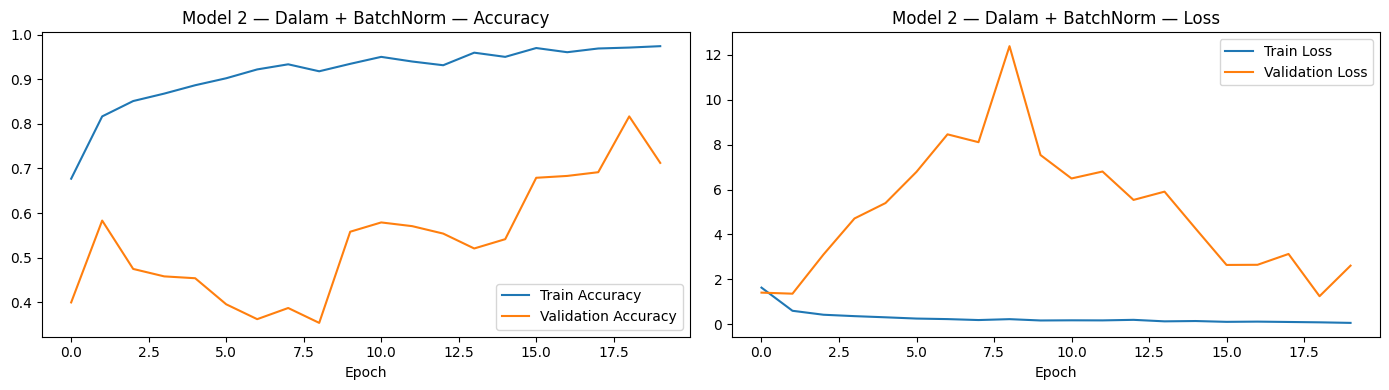

In [11]:
plot_history(history2, 'Model 2 — Dalam + BatchNorm')

### Interpretasi Grafik Training  Model 2 (Dalam + BatchNorm)

Berdasarkan grafik training Model 2:
- **Accuracy**: Akurasi train meningkat, namun kurva validasi menunjukkan fluktuasi lebih tinggi 
  dibanding Model 1, mengindikasikan model lebih sulit menstabilkan proses generalisasi.
- **Loss**: Loss validasi cenderung lebih tinggi dan tidak stabil dibanding loss training, 
  yang merupakan indikasi awal dari **overfitting** , model terlalu mempelajari pola pada 
  data training sehingga kurang optimal di data baru.
- Penggunaan BatchNormalization belum cukup mengatasi overfitting pada arsitektur yang lebih dalam 
  ini, kemungkinan karena jumlah data yang digunakan masih kurang untuk model ini  (400 gambar/kelas).

## 7. Evaluasi Model — Akurasi, Precision, Recall, F1-Score

In [12]:
def evaluate_model(model, X_test, y_test, class_names, model_name):
    score = model.evaluate(X_test, y_test, verbose=0)
    print(f'\n=== {model_name} ===')
    print(f'Test Loss     : {score[0]:.4f}')
    print(f'Test Accuracy : {score[1]:.4f}')

    preds = np.argmax(model.predict(X_test), axis=1)
    print('\nClassification Report:')
    print(classification_report(y_test, preds, target_names=class_names))
    return score[1], preds

acc1, pred1 = evaluate_model(model1, X_test, y_test, CLASSES, 'Model 1 — Sederhana')
acc2, pred2 = evaluate_model(model2, X_test, y_test, CLASSES, 'Model 2 — Dalam + BatchNorm')


=== Model 1 — Sederhana ===
Test Loss     : 0.3529
Test Accuracy : 0.8500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.82      0.70      0.76       100
      forest       0.93      0.92      0.92       100
    mountain       0.80      0.93      0.86       100

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


=== Model 2 — Dalam + BatchNorm ===
Test Loss     : 2.9300
Test Accuracy : 0.7000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       1.00      0.16      0.28       100
      forest       0.70      1.00      0.82       100
    mountain       0.67      0.94      0.78       100

    accuracy                           0.70       300
   macro avg       0.79      0.70      0.63       300
weighte

### Interpretasi Hasil Evaluasi

Berdasarkan classification report kedua model pada data test:

| Metrik    | Model 1 (Sederhana) | Model 2 (Dalam + BatchNorm) |
|-----------|---------------------|------------------------------|
| Accuracy  | **85.00%**          | 70.00%                       |
| Precision | **0.85**            | 0.79                         |
| Recall    | **0.85**            | 0.70                         |
| F1-Score  | **0.85**            | 0.63                         |

**Analisis per kelas pada Model 1:**
- Kelas `buildings` memiliki performa terendah dengan precision 0.82 dan recall 0.70 (F1: 0.76),
  mengindikasikan model cukup sering salah mengklasifikasikan gambar bangunan ke kelas lain.
- Kelas `forest` menunjukkan performa terbaik dengan F1-score 0.92, diikuti kelas `mountain`
  dengan F1-score 0.86.

**Analisis per kelas pada Model 2:**
- Kelas `buildings` menunjukkan anomali ekstrem: precision sempurna (1.00) namun recall
  sangat rendah (0.16) dengan F1-score hanya 0.28. Artinya dari 100 gambar `buildings`,
  model hanya berhasil mengenali 16 gambar dengan benar  sisanya salah diklasifikasikan
  ke kelas lain.
- Kelas `forest` memiliki recall 1.00 namun precision hanya 0.70, menunjukkan model
  cenderung *overpredict* kelas ini.
- Pola ini merupakan tanda kuat **overfitting** pada Model 2.

**Kesimpulan:** Model 1 (CNN Sederhana) terbukti lebih unggul dengan akurasi 85% dan
distribusi metrik yang jauh lebih seimbang antar kelas dibanding Model 2 (70%).

## 8. Perbandingan Hasil Evaluasi

In [14]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        'Accuracy' : round(np.mean(y_true == y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

comparison = pd.DataFrame([
    {'Model': 'Model 1 — Sederhana (2 Conv)',          **get_metrics(y_test, pred1)},
    {'Model': 'Model 2 — Dalam + BatchNorm (3 Conv)', **get_metrics(y_test, pred2)},
]).set_index('Model')

print('\n=== Tabel Perbandingan Model ===')
print(comparison.to_string())


=== Tabel Perbandingan Model ===
                                      Accuracy  Precision  Recall  F1-Score
Model                                                                      
Model 1 — Sederhana (2 Conv)              0.85     0.8515    0.85    0.8475
Model 2 — Dalam + BatchNorm (3 Conv)      0.70     0.7887    0.70    0.6263


### Interpretasi Tabel Perbandingan

Berdasarkan tabel perbandingan di atas, dapat disimpulkan bahwa:

- **Model 1 (CNN Sederhana, 2 Conv Layer)** secara keseluruhan mengungguli Model 2 pada semua metrik evaluasi.
- **Model 2 (CNN Dalam + BatchNorm, 3 Conv Layer)** menunjukkan performa yang lebih rendah, 
  dengan selisih akurasi sebesar **15%** dibanding Model 1. Ini mengindikasikan bahwa arsitektur 
  yang lebih dalam tidak selalu menghasilkan performa lebih baik, terutama ketika jumlah data 
  pelatihan terbatas.
- Nilai **F1-Score Model 2 (0.6263)** yang jauh lebih rendah dari Model 1 **(0.8475)** 
  menunjukkan ketidakseimbangan antara precision dan recall pada Model 2, yang merupakan 
  tanda overfitting.

## 9. Simpan Model (.h5)

In [15]:
model1.save('model1_sederhana.h5')
model2.save('model2_dalam_batchnorm.h5')
print('Model berhasil disimpan!')

Model berhasil disimpan!


## 10. Kesimpulan

Pada tugas ini telah dibangun dua model klasifikasi gambar menggunakan metode 
**Convolutional Neural Network (CNN)** pada dataset Intel Image Classification 
dengan 3 kelas: `buildings`, `forest`, dan `mountain`.

**Hasil Perbandingan Model:**

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Model 1 — Sederhana (2 Conv) | **0.85** | **0.8515** | **0.85** | **0.8475** |
| Model 2 — Dalam + BatchNorm (3 Conv) | 0.70 | 0.7887 | 0.70 | 0.6263 |

- **Model terbaik:** Model 1 (CNN Sederhana, 2 Conv Layer) dengan akurasi test **85%** 
  dan F1-Score **0.8475**, unggul di semua metrik dibanding Model 2.

- **Perbedaan utama:** Meskipun Model 2 menggunakan arsitektur yang lebih dalam (3 Conv Layer) 
  dan dilengkapi BatchNormalization, model ini justru menunjukkan gejala **overfitting**  
  terbukti dari nilai F1-Score yang rendah (0.6263) akibat ketidakseimbangan antara precision 
  dan recall. Hal ini kemungkinan disebabkan oleh jumlah data training yang terbatas 
  (400 gambar/kelas), sehingga arsitektur yang lebih kompleks tidak cukup data untuk belajar 
  secara optimal.

- **Kelas yang paling sulit diklasifikasi:** Berdasarkan classification report, kelas 
  `buildings` menjadi yang paling sulit diklasifikasi pada kedua model, dengan F1-Score 
  terendah. Hal ini kemungkinan karena fitur visual bangunan memiliki variasi tinggi dan 
  terkadang menyerupai fitur kelas lain.